In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']
df_list = []

# Loop, Load, Label, and Store
for country in countries:
    path = f'../data/{country}_clean.csv'
    temp_df = pd.read_csv(path)
    
    # CRITICAL: Add the country name as a column BEFORE appending
    temp_df['Country'] = country 
    
    df_list.append(temp_df)
    print(f"Loaded {country}: {len(temp_df)} rows")

# Concatenate all
master_df = pd.concat(df_list, ignore_index=True)

# Verification
print("\n--- Verification ---")
print(master_df['Country'].value_counts()) # This should show ~4000 rows per country

Loaded ethiopia: 4108 rows
Loaded kenya: 4108 rows
Loaded sudan: 4108 rows
Loaded tanzania: 4108 rows
Loaded nigeria: 4108 rows

--- Verification ---
Country
ethiopia    4108
kenya       4108
sudan       4108
tanzania    4108
nigeria     4108
Name: count, dtype: int64


Temperature & Precipitation Comparison

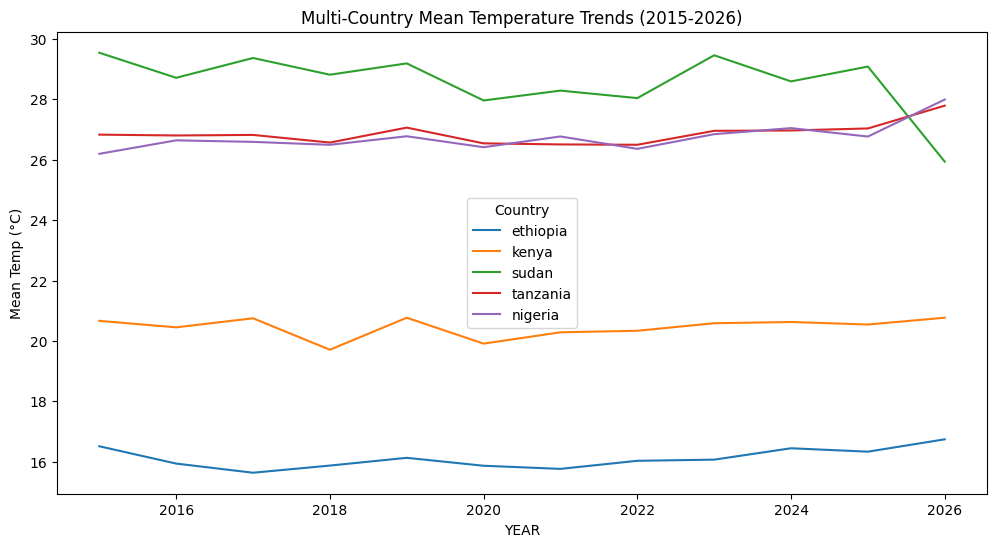

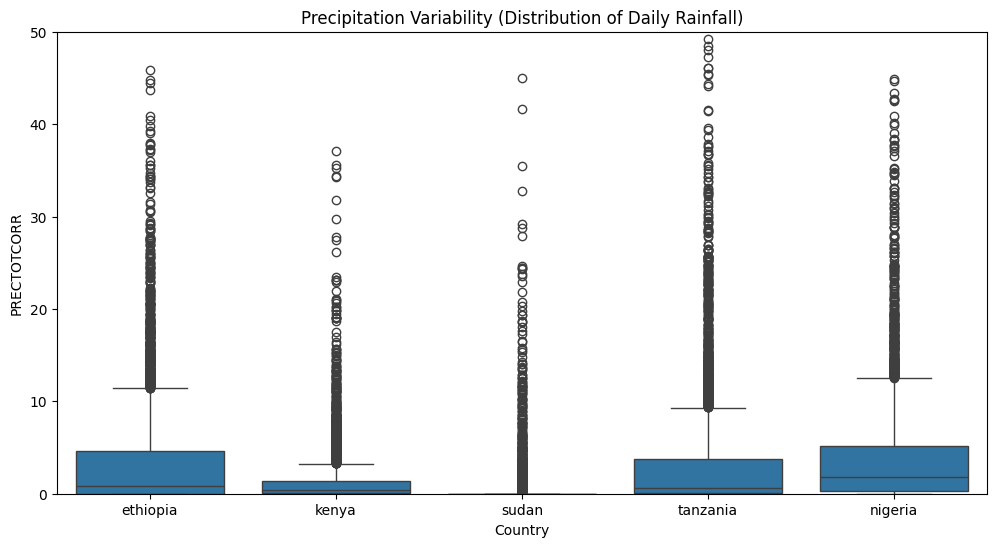

In [15]:
# Temperature Trend: Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=master_df, x='YEAR', y='T2M', hue='Country', estimator='mean', errorbar=None)
plt.title('Multi-Country Mean Temperature Trends (2015-2026)')
plt.ylabel('Mean Temp (°C)')
plt.show()

# Precipitation Comparison: Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=master_df, x='Country', y='PRECTOTCORR')
plt.title('Precipitation Variability (Distribution of Daily Rainfall)')
plt.ylim(0, 50) # Zoom in to see the bulk of the data
plt.show()

Extreme Event Analysis

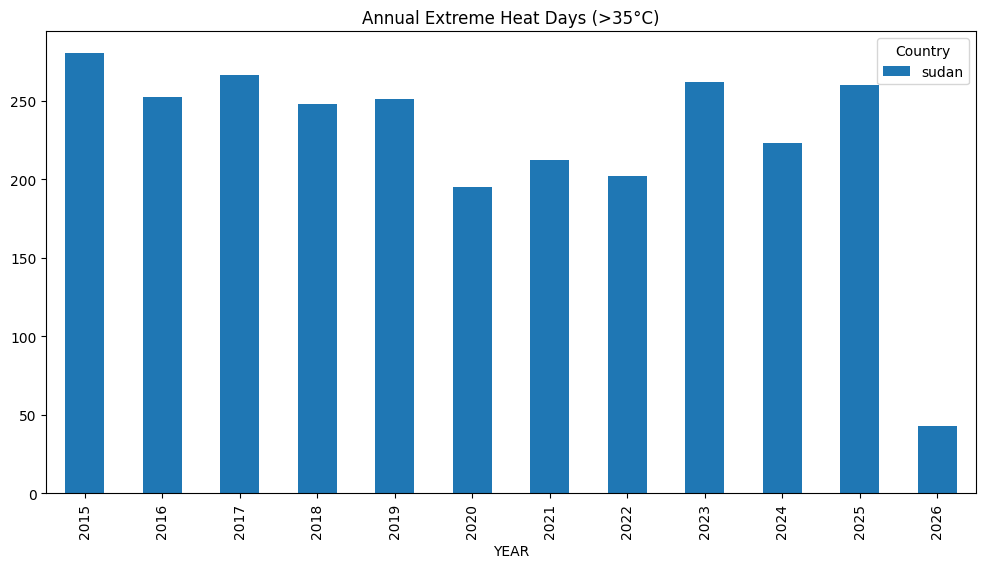

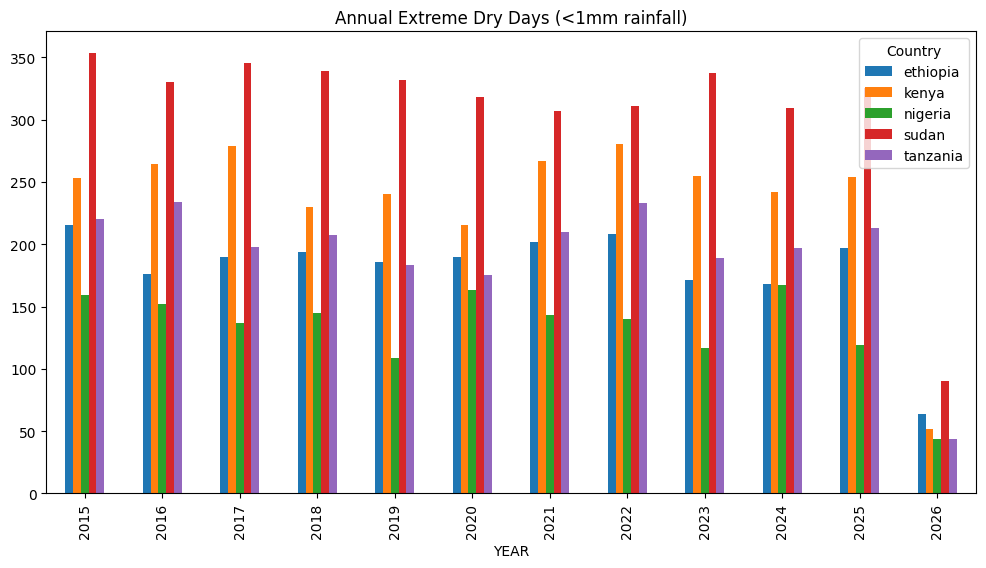

In [17]:
# 1. Heat Stress: Count days > 35°C per year
heat_df = master_df[master_df['T2M_MAX'] > 35].groupby(['Country', 'YEAR']).size().reset_index(name='Heat_Days')
heat_matrix = heat_df.pivot_table(index='YEAR', columns='Country', values='Heat_Days', fill_value=0)
heat_matrix.plot(kind='bar', figsize=(12, 6))
plt.title('Annual Extreme Heat Days (>35°C)')
plt.show()

# 2. Dry Days: Count days < 1mm rainfall per year
dry_df = master_df[master_df['PRECTOTCORR'] < 1].groupby(['Country', 'YEAR']).size().reset_index(name='Dry_Days')
dry_matrix = dry_df.pivot_table(index='YEAR', columns='Country', values='Dry_Days', fill_value=0)
dry_matrix.plot(kind='bar', figsize=(12, 6))
plt.title('Annual Extreme Dry Days (<1mm rainfall)')
plt.show()

Vulnerability Ranking Table

In [19]:
# 1. Calculate aggregate metrics
vuln_stats = master_df.groupby('Country').agg({
    'T2M': ['mean', 'std'],
    'PRECTOTCORR': ['mean', 'std']
})

# 2. FLATTEN the MultiIndex columns
# This converts ('T2M', 'mean') into 'T2M_mean'
vuln_stats.columns = ['_'.join(col).strip() for col in vuln_stats.columns.values]

# 3. Reset index so 'Country' becomes a column again
vuln_stats = vuln_stats.reset_index()

# 4. Now calculate extremes and merge
extremes = master_df[(master_df['T2M_MAX'] > 35) | (master_df['PRECTOTCORR'] < 1)].groupby('Country').size().reset_index(name='Extreme_Event_Count')

# Now the merge will work perfectly!
summary_table = pd.merge(vuln_stats, extremes, on='Country')

# Sort and display
summary_table = summary_table.sort_values(by='Extreme_Event_Count', ascending=False)
print(summary_table)

    Country   T2M_mean   T2M_std  PRECTOTCORR_mean  PRECTOTCORR_std  \
3     sudan  28.759007  4.681305          0.643875         3.057672   
1     kenya  20.427600  1.440824          1.468162         3.180228   
4  tanzania  26.802422  1.325388          3.740256         8.003947   
0  ethiopia  16.068500  1.898050          3.633795         6.289061   
2   nigeria  26.656928  1.123335          4.213914         7.266742   

   Extreme_Event_Count  
3                 3859  
1                 2831  
4                 2303  
0                 2161  
2                 1595  


In [20]:
# T2M Summary Table
t2m_summary = master_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).reset_index()
print("--- T2M Summary Table ---")
print(t2m_summary)

# PRECTOTCORR Summary Table
precip_summary = master_df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).reset_index()
print("\n--- Precipitation Summary Table ---")
print(precip_summary)

--- T2M Summary Table ---
    Country       mean  median       std
0  ethiopia  16.068500   16.04  1.898050
1     kenya  20.427600   20.36  1.440824
2   nigeria  26.656928   26.82  1.123335
3     sudan  28.759007   29.16  4.681305
4  tanzania  26.802422   26.99  1.325388

--- Precipitation Summary Table ---
    Country      mean  median       std
0  ethiopia  3.633795    0.82  6.289061
1     kenya  1.468162    0.38  3.180228
2   nigeria  4.213914    1.84  7.266742
3     sudan  0.643875    0.00  3.057672
4  tanzania  3.740256    0.64  8.003947


In [21]:
# Get aggregate stats for T2M
stats = master_df.groupby('Country').agg({
    'T2M': ['mean', 'median', 'std'],
    'PRECTOTCORR': ['mean', 'median', 'std']
})
# Flatten columns
stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
stats = stats.reset_index()

# Merge with Extreme Event Counts
summary_table = pd.merge(stats, summary_table[['Country', 'Extreme_Event_Count']], on='Country')

# Sort to show highest vulnerability first
summary_table = summary_table.sort_values(by='Extreme_Event_Count', ascending=False)
print("--- Final Vulnerability Ranking ---")
print(summary_table)

--- Final Vulnerability Ranking ---
    Country   T2M_mean  T2M_median   T2M_std  PRECTOTCORR_mean  \
3     sudan  28.759007       29.16  4.681305          0.643875   
1     kenya  20.427600       20.36  1.440824          1.468162   
4  tanzania  26.802422       26.99  1.325388          3.740256   
0  ethiopia  16.068500       16.04  1.898050          3.633795   
2   nigeria  26.656928       26.82  1.123335          4.213914   

   PRECTOTCORR_median  PRECTOTCORR_std  Extreme_Event_Count  
3                0.00         3.057672                 3859  
1                0.38         3.180228                 2831  
4                0.64         8.003947                 2303  
0                0.82         6.289061                 2161  
2                1.84         7.266742                 1595  
